<a href="https://colab.research.google.com/github/woodmc10/rugby/blob/main/notebooks/movinet_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MoViNet Fine Tuning

This notebook is an edit of the Colab Movinet Tutorial [notebook](https://colab.research.google.com/github/tensorflow/models/blob/master/official/projects/movinet/movinet_tutorial.ipynb). The original sections for running, streaming, and exporting base models has been removed and only the fine tuning section remains. The code has been editted to fit my use case.

## Steps
1. Mount Google Drive to VM
1. Create a tensorflow dataset
1. Download a movinet model
1. Fine tune the model

## Setup

For fine-tuning, it is recommended to run the models using GPUs.

To select a GPU in Colab, select `Runtime > Change runtime type > Hardware accelerator > T4 GPU` dropdown in the top menu.

In [2]:
# Install packages

# tf-models-official is the stable Model Garden package
# tf-models-nightly includes latest changes
!pip install -U -q "tf-models-official"


# Install the mediapy package for visualizing images/videos.
# See https://github.com/google/mediapy
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy

# Need an older version of Matplotlib for plots with FigureCanvasAgg
!pip install matplotlib==3.7.0

# inference works on CPU but not T4 GPU (crashes) or v2-8 TPU (error listed above)
# Fine tuning requires the T4 GPU runtime hardware

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 9.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.6

In [1]:
# Run imports

# Need to use legacy keras to avoid an error about keras and numpy arrays
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import cv2
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import mediapy as media
import numpy as np
import PIL
import pandas as pd
import shutil
import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow_hub as hub
import tqdm
import absl.logging

from datetime import datetime
from google.colab import drive
from pathlib import Path
from official.vision.configs import video_classification
from official.projects.movinet.configs import movinet as movinet_configs
from official.projects.movinet.modeling import movinet
from official.projects.movinet.modeling import movinet_layers
from official.projects.movinet.modeling import movinet_model


tf.get_logger().setLevel('ERROR')
absl.logging.set_verbosity(absl.logging.ERROR)
mpl.rcParams.update({
    'font.size': 10,
})

Run the cell below to define helper functions and create variables.

In [2]:
#@title Run this cell to set up some helper code.

# Download Kinetics 600 label map
!wget https://raw.githubusercontent.com/tensorflow/models/f8af2291cced43fc9f1d9b41ddbf772ae7b0d7d2/official/projects/movinet/files/kinetics_600_labels.txt -O labels.txt -q

with tf.io.gfile.GFile('labels.txt') as f:
  lines = f.readlines()
  KINETICS_600_LABELS_LIST = [line.strip() for line in lines]
  KINETICS_600_LABELS = tf.constant(KINETICS_600_LABELS_LIST)

def get_top_k(probs, k=5, label_map=KINETICS_600_LABELS):
  """Outputs the top k model labels and probabilities on the given video."""
  top_predictions = tf.argsort(probs, axis=-1, direction='DESCENDING')[:k]
  top_labels = tf.gather(label_map, top_predictions, axis=-1)
  top_labels = [label.decode('utf8') for label in top_labels.numpy()]
  top_probs = tf.gather(probs, top_predictions, axis=-1).numpy()
  return tuple(zip(top_labels, top_probs))

def predict_top_k(model, video, k=5, label_map=KINETICS_600_LABELS):
  """Outputs the top k model labels and probabilities on the given video."""
  outputs = model.predict(video[tf.newaxis])[0]
  probs = tf.nn.softmax(outputs)
  return get_top_k(probs, k=k, label_map=label_map)

def load_movinet_from_hub(model_id, model_mode, hub_version=3):
  """Loads a MoViNet model from TF Hub."""
  hub_url = f'https://tfhub.dev/tensorflow/movinet/{model_id}/{model_mode}/kinetics-600/classification/{hub_version}'

  encoder = hub.KerasLayer(hub_url, trainable=True)

  inputs = tf.keras.layers.Input(
      shape=[None, None, None, 3],
      dtype=tf.float32)

  if model_mode == 'base':
    inputs = dict(image=inputs)
  else:
    # Define the state inputs, which is a dict that maps state names to tensors.
    init_states_fn = encoder.resolved_object.signatures['init_states']
    state_shapes = {
        name: ([s if s > 0 else None for s in state.shape], state.dtype)
        for name, state in init_states_fn(tf.constant([0, 0, 0, 0, 3])).items()
    }
    states_input = {
        name: tf.keras.Input(shape[1:], dtype=dtype, name=name)
        for name, (shape, dtype) in state_shapes.items()
    }

    # The inputs to the model are the states and the video
    inputs = {**states_input, 'image': inputs}

  # Output shape: [batch_size, 600]
  outputs = encoder(inputs)

  model = tf.keras.Model(inputs, outputs)
  model.build([1, 1, 1, 1, 3])

  return model

# Download example gif
!wget https://github.com/tensorflow/models/raw/f8af2291cced43fc9f1d9b41ddbf772ae7b0d7d2/official/projects/movinet/files/jumpingjack.gif -O jumpingjack.gif -q

def load_gif(file_path, image_size=(224, 224)):
  """Loads a gif file into a TF tensor."""
  with tf.io.gfile.GFile(file_path, 'rb') as f:
    video = tf.io.decode_gif(f.read())
  video = tf.image.resize(video, image_size)
  video = tf.cast(video, tf.float32) / 255.
  return video

def get_top_k_streaming_labels(probs, k=5, label_map=KINETICS_600_LABELS_LIST):
  """Returns the top-k labels over an entire video sequence.

  Args:
    probs: probability tensor of shape (num_frames, num_classes) that represents
      the probability of each class on each frame.
    k: the number of top predictions to select.
    label_map: a list of labels to map logit indices to label strings.

  Returns:
    a tuple of the top-k probabilities, labels, and logit indices
  """
  top_categories_last = tf.argsort(probs, -1, 'DESCENDING')[-1, :1]
  categories = tf.argsort(probs, -1, 'DESCENDING')[:, :k]
  categories = tf.reshape(categories, [-1])

  counts = sorted([
      (i.numpy(), tf.reduce_sum(tf.cast(categories == i, tf.int32)).numpy())
      for i in tf.unique(categories)[0]
  ], key=lambda x: x[1], reverse=True)

  top_probs_idx = tf.constant([i for i, _ in counts[:k]])
  top_probs_idx = tf.concat([top_categories_last, top_probs_idx], 0)
  top_probs_idx = tf.unique(top_probs_idx)[0][:k+1]

  top_probs = tf.gather(probs, top_probs_idx, axis=-1)
  top_probs = tf.transpose(top_probs, perm=(1, 0))
  top_labels = tf.gather(label_map, top_probs_idx, axis=0)
  top_labels = [label.decode('utf8') for label in top_labels.numpy()]

  return top_probs, top_labels, top_probs_idx

def plot_streaming_top_preds_at_step(
    top_probs,
    top_labels,
    step=None,
    image=None,
    legend_loc='lower left',
    duration_seconds=10,
    figure_height=500,
    playhead_scale=0.8,
    grid_alpha=0.3):
  """Generates a plot of the top video model predictions at a given time step.

  Args:
    top_probs: a tensor of shape (k, num_frames) representing the top-k
      probabilities over all frames.
    top_labels: a list of length k that represents the top-k label strings.
    step: the current time step in the range [0, num_frames].
    image: the image frame to display at the current time step.
    legend_loc: the placement location of the legend.
    duration_seconds: the total duration of the video.
    figure_height: the output figure height.
    playhead_scale: scale value for the playhead.
    grid_alpha: alpha value for the gridlines.

  Returns:
    A tuple of the output numpy image, figure, and axes.
  """
  num_labels, num_frames = top_probs.shape
  if step is None:
    step = num_frames

  fig = plt.figure(figsize=(6.5, 7), dpi=300)
  gs = mpl.gridspec.GridSpec(8, 1)
  ax2 = plt.subplot(gs[:-3, :])
  ax = plt.subplot(gs[-3:, :])

  if image is not None:
    ax2.imshow(image, interpolation='nearest')
    ax2.axis('off')

  preview_line_x = tf.linspace(0., duration_seconds, num_frames)
  preview_line_y = top_probs

  line_x = preview_line_x[:step+1]
  line_y = preview_line_y[:, :step+1]

  for i in range(num_labels):
    ax.plot(preview_line_x, preview_line_y[i], label=None, linewidth='1.5',
            linestyle=':', color='gray')
    ax.plot(line_x, line_y[i], label=top_labels[i], linewidth='2.0')


  ax.grid(which='major', linestyle=':', linewidth='1.0', alpha=grid_alpha)
  ax.grid(which='minor', linestyle=':', linewidth='0.5', alpha=grid_alpha)

  min_height = tf.reduce_min(top_probs) * playhead_scale
  max_height = tf.reduce_max(top_probs)
  ax.vlines(preview_line_x[step], min_height, max_height, colors='red')
  ax.scatter(preview_line_x[step], max_height, color='red')

  ax.legend(loc=legend_loc)

  plt.xlim(0, duration_seconds)
  plt.ylabel('Probability')
  plt.xlabel('Time (s)')
  plt.yscale('log')

  fig.tight_layout()
  fig.canvas.draw()

  data = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
  data = data.reshape(fig.canvas.get_width_height()[::-1] + (3,))
  plt.close()

  figure_width = int(figure_height * data.shape[1] / data.shape[0])
  image = PIL.Image.fromarray(data).resize([figure_width, figure_height])
  image = np.array(image)

  return image, (fig, ax, ax2)

def plot_streaming_top_preds(
    probs,
    video,
    top_k=5,
    video_fps=25.,
    figure_height=500,
    use_progbar=True):
  """Generates a video plot of the top video model predictions.

  Args:
    probs: probability tensor of shape (num_frames, num_classes) that represents
      the probability of each class on each frame.
    video: the video to display in the plot.
    top_k: the number of top predictions to select.
    video_fps: the input video fps.
    figure_fps: the output video fps.
    figure_height: the height of the output video.
    use_progbar: display a progress bar.

  Returns:
    A numpy array representing the output video.
  """
  video_fps = 8.
  figure_height = 500
  steps = video.shape[0]
  duration = steps / video_fps

  top_probs, top_labels, _ = get_top_k_streaming_labels(probs, k=top_k)

  images = []
  step_generator = tqdm.trange(steps) if use_progbar else range(steps)
  for i in step_generator:
    image, _ = plot_streaming_top_preds_at_step(
        top_probs=top_probs,
        top_labels=top_labels,
        step=i,
        image=video[i],
        duration_seconds=duration,
        figure_height=figure_height,
    )
    images.append(image)

  return np.array(images)

  def load_annotations(json_path):
    """Load annotations from exported JSON file."""
    with open(json_path, 'r') as f:
        annotations = json.load(f)
    return annotations
# ------------------------------------------------------------------------- #
# End of Tutorial Code



# Start of dataset code - developed from Claude file
# ------------------------------------------------------------------------- #
def load_annotations(json_path):
    """Load annotations from exported JSON file."""
    with open(json_path, 'r') as f:
        annotations = json.load(f)
    return annotations


def extract_video_clips(video_path, annotations, output_dir, clip_length=64):
    """
    Extract video clips based on annotations and save them.

    Args:
        video_path: Path to source video
        annotations: Loaded annotations dictionary
        output_dir: Directory to save clips
        clip_length: Number of frames per clip
    """
    # Create output directory
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)

    # Open video
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)

    # Process each annotation
    clips_info = []
    for tag in annotations['tags']:
        action = tag['name']
        if not action:
            continue

        # assume the end frame is the end of the tackle,
        # take a set number of frames for the clip
        start_frame = tag['frameRange'][1] - clip_length
        end_frame = tag['frameRange'][1]

        # Set video to start frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

        # Calculate number of frames in sequence
        n_frames = end_frame - start_frame

        # Read frames
        frames = []
        for _ in range(n_frames):
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(frame)

        clip_name = f"{action}_{start_frame}.mp4"
        clip_folder = output_dir / action
        clip_folder = Path(clip_folder)
        clip_folder.mkdir(exist_ok=True, parents=True)
        clip_path = clip_folder / clip_name

        # Save clip
        out = cv2.VideoWriter(
            str(clip_path),
            cv2.VideoWriter_fourcc(*'mp4v'),
            fps,
            (frames[0].shape[1], frames[0].shape[0])
        )

        for frame in frames:
            out.write(frame)
        out.release()

        clips_info.append({
            'clip_path': str(clip_path),
            'action': action,
            'start_frame': start_frame,
            'end_frame': end_frame
        })

    cap.release()
    return pd.DataFrame(clips_info)



def create_tf_dataset(clips_df, frame_size=(224, 224)):
    """
    Create TensorFlow dataset from clips. Use for local TF datasets.

    Args:
        clips_df: DataFrame with clip information
        frame_size: Target frame size (height, width)
    """
    def load_video(path_tensor, label):
        # Convert tensor to string
        path = path_tensor.numpy().decode('utf-8')

        # Read video file
        cap = cv2.VideoCapture(path)
        if not cap.isOpened():
            print(f"Failed to open video: {path}")
            return np.zeros((1, *frame_size, 3), dtype=np.float32), label

        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            # Resize frame
            frame = cv2.resize(frame, frame_size)
            # Convert BGR to RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        cap.release()

        if not frames:
            print(f"No frames read from: {path}")
            return np.zeros((1, *frame_size, 3), dtype=np.float32), label

        return np.array(frames, dtype=np.float32), label

    # Create label mapping
    labels = sorted(clips_df['action'].unique())
    label_to_index = {label: i for i, label in enumerate(labels)}

    # Create dataset
    paths = clips_df['clip_path'].values
    labels = [label_to_index[label] for label in clips_df['action']]

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(
        lambda x, y: tf.py_function(
            load_video,
            [x, y],
            [tf.float32, tf.int32]
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    return dataset, label_to_index


def test_dataset_loading(clips_df):
    """Test dataset creation with a single clip."""
    # Take first clip
    test_df = clips_df.iloc[[0]]
    clip_path = test_df['clip_path'].iloc[0]

    # Test direct video loading first
    print(f"\nTesting direct video loading for: {clip_path}")
    cap = cv2.VideoCapture(clip_path)
    if not cap.isOpened():
        print("Failed to open video directly with OpenCV")
    else:
        ret, frame = cap.read()
        if not ret:
            print("Failed to read first frame")
        else:
            print(f"Successfully read frame with shape: {frame.shape}")
    cap.release()

    # Now test through TensorFlow
    print("\nTesting through TensorFlow dataset:")
    dataset, label_mapping = create_tf_dataset(test_df)

    try:
        for frames, label in dataset.take(1):
            print(f"Frames shape: {frames.shape}")
            print(f"Label: {label.numpy()}")
    except Exception as e:
        print(f"Error during dataset iteration: {str(e)}")

    return dataset, label_mapping


def one_hot_encode(label, num_classes):
    """
    Converts an integer label to a one-hot encoded tensor.

    Args:
        label (int): The class label.
        num_classes (int): Total number of classes.

    Returns:
        Tensor: One-hot encoded label.
    """
    return tf.one_hot(label, depth=num_classes)


def process_video_data(video_path, annotations_path, output_dir, clip_length):
    """Main processing function."""
    # Load annotations
    annotations = load_annotations(annotations_path)

    # Extract clips
    clips_df = extract_video_clips(video_path, annotations, output_dir, clip_length)

    return clips_df

## Fine-Tune a Base Model with the TensorFlow Model Garden

MoViNet-A0-Base is fine tuned on video clips from rugby games.

The following code will:

- Mount Google Drive to the VM.
- Unzip a data folder with the necessary video and annotation files.
- Extract the training clips from the larger video and create a tensorflow dataset.
- Display some example videos from the dataset.
- Build a MoViNet model and load pretrained weights.
- Fine-tune the final classifier layers on rugby data and evaluate accuracy on the validation set.

### Mount Google Drive and Extract Files

In [5]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [6]:
!unzip drive/MyDrive/Rugby_DVC/data.zip -d .

Archive:  drive/MyDrive/Rugby_DVC/data.zip
   creating: ./data/
   creating: ./data/rugby_7s/
  inflating: ./data/rugby_7s/.DS_Store  
  inflating: ./data/rugby_7s/key_id_map.json  
   creating: ./data/rugby_7s/dataset_2025_01_23/
   creating: ./data/rugby_7s/dataset_2025_01_23/video/
  inflating: ./data/rugby_7s/dataset_2025_01_23/video/usd_loyola.mp4  
   creating: ./data/rugby_7s/dataset_2025_01_23/ann/
  inflating: ./data/rugby_7s/dataset_2025_01_23/ann/usd_loyola.json  
  inflating: ./data/rugby_7s/dataset_2025_01_23/.DS_Store  
   creating: ./data/rugby_7s/dataset_2025_01_23/dataset/
   creating: ./data/rugby_7s/dataset_2025_01_23/dataset/usd_loyola/
   creating: ./data/rugby_7s/dataset_2025_01_23/dataset/usd_loyola/white_tackle/
  inflating: ./data/rugby_7s/dataset_2025_01_23/dataset/usd_loyola/white_tackle/white_tackle_21527.mp4  
  inflating: ./data/rugby_7s/dataset_2025_01_23/dataset/usd_loyola/white_tackle/white_tackle_21295.mp4  
  inflating: ./data/rugby_7s/dataset_2025_01

In [7]:
clip_len = 40
# Extract clips from all matches
anno_list = os.listdir('/content/data/rugby_7s/dataset_2025_01_23/ann/')
anno_dfs = []
for anno in anno_list:
  if anno == 'usd_loyola.json':
    continue
  anno_name = anno.split('.')[0]
  print(anno_name)
  df = process_video_data(
      f'/content/data/rugby_7s/dataset_2025_01_23/video/{anno_name}.mp4',
      f'/content/data/rugby_7s/dataset_2025_01_23/ann/{anno_name}.json',
      f'/content/data/rugby_7s/dataset_2025_01_23/dataset/{anno_name}/',
      clip_length=clip_len)
  anno_dfs.append(df)
training_df = pd.concat(anno_dfs)
validation_df = process_video_data(
      '/content/data/rugby_7s/dataset_2025_01_23/video/usd_loyola.mp4',
      '/content/data/rugby_7s/dataset_2025_01_23/ann/usd_loyola.json',
      '/content/data/rugby_7s/dataset_2025_01_23/dataset/usd_loyola/',
      clip_length=clip_len)

2024_ocaa_game7
2024_ocaa_game4
2024_ocaa_game5
2024_ocaa_game3
2024_ocaa_game6
2024_ocaa_game1
2024_ocaa_game2


In [8]:
# Condense white_tackle and dark_tackle labels into a single "tackle" category
training_df['action'] = training_df['action'].replace({'white_tackle': 'tackle', 'dark_tackle': 'tackle'})
validation_df['action'] = validation_df['action'].replace({'white_tackle': 'tackle', 'dark_tackle': 'tackle'})

## Create Tensorflow Dataset

In [9]:
# Create training dataset
training_dataset, label_mapping = create_tf_dataset(training_df)

# Local dataset creation
# Add batching and prefetching for training
training_dataset = training_dataset.batch(16).prefetch(tf.data.AUTOTUNE)

# Verify dataset structure
for frames, labels in training_dataset.take(1):
    print(f"Batch shape: {frames.shape}")
    print(f"Labels shape: {labels.shape}")

num_classes = len(np.unique(labels.numpy()))

# prepare the dataset for training
# repeat(): Prevents dataset from stopping after one pass.
# prefetch(2): Improves performance by preloading 2 batches ahead of time.
train_dataset = training_dataset.repeat()
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

# Apply one-hot encoding in dataset pipeline
train_dataset = train_dataset.map(lambda x, y: (x, one_hot_encode(y, num_classes)))

Batch shape: (16, 40, 224, 224, 3)
Labels shape: (16,)


In [10]:
# Create validation dataset
validation_dataset, label_mapping = create_tf_dataset(validation_df)

# Local dataset creation
# Add batching and prefetching for training
validation_dataset = validation_dataset.batch(16).prefetch(tf.data.AUTOTUNE)

# Verify dataset structure
for frames, labels in validation_dataset.take(1):
    print(f"Batch shape: {frames.shape}")
    print(f"Labels shape: {labels.shape}")

# prefetch(2): Improves performance by preloading 2 batches ahead of time.
validation_dataset = validation_dataset.prefetch(tf.data.AUTOTUNE)

# Apply one-hot encoding in dataset pipeline
validation_dataset = validation_dataset.map(lambda x, y: (x, one_hot_encode(y, num_classes)))

Batch shape: (16, 40, 224, 224, 3)
Labels shape: (16,)


Display some example videos from the dataset.

""

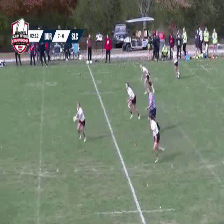

In [11]:
# Preview the first video
for sample in train_dataset.take(1):  # Take one batch
    video, label = sample
    video_np = video.numpy()[0]  # Convert first sample in batch to NumPy
    video_np = video_np.astype(np.uint8)
    label = label.numpy()[0]
media.show_video(video_np, codec='gif', fps=10)

### Build MoViNet-A0-Base and Load Pretrained Weights

Here we create a MoViNet model using the open source code provided in [official/projects/movinet](https://github.com/tensorflow/models/tree/master/official/projects/movinet) and load the pretrained weights. Here we freeze the all layers except the final classifier head to speed up fine-tuning.

In [ ]:
batch_size = 8
num_frames = 8
frame_stride = 10
resolution = 172

model_id = 'a0'

tf.keras.backend.clear_session()

backbone = movinet.Movinet(model_id=model_id)
model = movinet_model.MovinetClassifier(backbone=backbone, num_classes=600)
model.build([1, 1, 1, 1, 3])

# Load pretrained weights
!wget https://storage.googleapis.com/tf_model_garden/vision/movinet/movinet_a0_base.tar.gz -O movinet_a0_base.tar.gz -q
!tar -xvf movinet_a0_base.tar.gz

checkpoint_dir = 'movinet_a0_base'
checkpoint_path = tf.train.latest_checkpoint(checkpoint_dir)
checkpoint = tf.train.Checkpoint(model=model)
status = checkpoint.restore(checkpoint_path)
status.assert_existing_objects_matched()

def build_classifier(backbone, num_classes, freeze_backbone=False):
  """Builds a classifier on top of a backbone model."""
  model = movinet_model.MovinetClassifier(
      backbone=backbone,
      num_classes=num_classes)
  model.build([batch_size, num_frames, resolution, resolution, 3])

  if freeze_backbone:
    for layer in model.layers[:-1]:
      layer.trainable = False
    model.layers[-1].trainable = True

  return model

# Wrap the backbone with a new classifier to create a new classifier head
# with num_classes outputs.
# Freeze all layers except for the final classifier head.
model = build_classifier(backbone, num_classes, freeze_backbone=True)

Configure fine-tuning with training/evaluation steps, loss object, metrics, learning rate, optimizer, and callbacks.

Here we use 3 epochs. Training for more epochs should improve accuracy.

In [ ]:
num_epochs = 30

# train_steps = num_examples['train'] // batch_size
train_steps = 16 // batch_size
total_train_steps = train_steps * num_epochs
# test_steps = num_examples['test'] // batch_size
test_steps = 16 // batch_size

loss_obj = tf.keras.losses.CategoricalCrossentropy(
    from_logits=True,
    label_smoothing=0.1)

metrics = [
    tf.keras.metrics.TopKCategoricalAccuracy(
        k=1, name='top_1', dtype=tf.float32),
    # tf.keras.metrics.TopKCategoricalAccuracy(
    #     k=5, name='top_5', dtype=tf.float32),
]

initial_learning_rate = 0.0001 # originally 0.01
learning_rate = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate, decay_steps=total_train_steps,
)
optimizer = tf.keras.optimizers.RMSprop(
    learning_rate, rho=0.9, momentum=0.9, epsilon=1.0, clipnorm=1.0)

model.compile(loss=loss_obj, optimizer=optimizer, metrics=metrics)

callbacks = [
    tf.keras.callbacks.TensorBoard(),
]

Run the fine-tuning with Keras compile/fit. After fine-tuning the model, we should be able to achieve >85% accuracy on the test set.

In [ ]:
results = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=num_epochs,
    steps_per_epoch=train_steps,
    validation_steps=test_steps,
    callbacks=callbacks,
    validation_freq=1,
    verbose=1)

We can also view the training and evaluation progress in TensorBoard.

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
print(timestamp)

# save just the weights:
weights_save_path = f'/content/drive/MyDrive/Rugby_DVC/saved_models/{timestamp}_model_weights.h5'
model.save_weights(weights_save_path)

In [ ]:
%reload_ext tensorboard
%tensorboard --logdir logs --port 0

In [ ]:
# prompt: view every video in the train_dataset

# import matplotlib.pyplot as plt
# import mediapy as media
# import numpy as np

# Assuming 'train_dataset' is already defined as in the provided code
for sample in train_dataset.take(len(list(train_dataset))):
# for sample in train_dataset.take(2):
    video, label = sample
    video_np = video.numpy()[0]
    video_np = video_np.astype(np.uint8)
    label = label.numpy()[0]
    media.show_video(video_np, codec='gif', fps=10)
    plt.title(f"Label: {label}") # Add label to title
    plt.show()
